<a href="https://colab.research.google.com/github/anjicx/CNHypergraph/blob/main/Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

from google.colab import drive
drive.mount("/content/drive", force_remount=True)

from pathlib import Path
import warnings

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from IPython.display import display, Image

warnings.filterwarnings("ignore")

output_dir = Path("/content/drive/MyDrive/PatientData/hgnn_statistics")
plot_dir = output_dir / "plots_descriptive_simple"
plot_dir.mkdir(parents=True, exist_ok=True)

groups = ["Male", "Female"]


def group_path(group, filename):
    return output_dir / group.lower() / filename


def save_plot(filename):
    path = plot_dir / filename
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    print("saved:", path)


def clean_axes(xlabel="", ylabel=""):
    ax = plt.gca()
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def plot_ccdf(values, label):
    values = pd.Series(values).replace([np.inf, -np.inf], np.nan).dropna()
    values = values[values > 0].sort_values().values

    if len(values) == 0:
        return

    y = 1.0 - np.arange(1, len(values) + 1) / len(values)
    plt.plot(values, y, marker=".", linestyle="none", markersize=3, label=label)

Mounted at /content/drive


# STRUCTURAL STATISTICS

STRUCTURAL HYPERGRAPH STATISTICS
Question: What does the patient-diagnosis hypergraph look like?

In this hypergraph:
 node / vertex = diagnosis

 hyperedge = patient

 membership = patient to diagnosis connection

 sex and age_group = patient-level labels for subgroup comparison

1. Number of hyperedges
   -> How many patients are included in this hypergraph/subgroup?

2. Number of diagnosis nodes
   -> How many different diagnoses appear in this hypergraph/subgroup?

3. Number of patient-diagnosis connections / memberships
   -> How many total unique patient-diagnosis links exist?
   -> How much total disease burden is represented through patient-diagnosis connections?

4. Incidence density
   -> What proportion of all possible patient-diagnosis links actually exists?
   -> How connected is the patient-diagnosis incidence matrix?

5. Incidence sparsity
   -> How empty is the patient-diagnosis incidence matrix?
   -> How many possible patient-diagnosis links are absent?

6. Hyperedge size
   -> How many unique diagnoses does each patient have?
   -> What is the typical multimorbidity burden per patient?
   -> What is the maximum disease burden observed in one patient?

7. Node degree
   -> How many patients have each diagnosis?
   -> Which diagnoses are common and which diagnoses are rare?

8. Rare diagnosis statistics
   -> How many diagnoses appear in only a few patients?
   -> Is the diagnosis distribution dominated by rare diagnoses?

9. Top diagnoses
   -> Which ICD diagnosis codes are most frequent in this group?
   -> Which diagnoses dominate the hypergraph?


In [ ]:
basic = pd.read_csv(output_dir / "combined_basic_hypergraph_statistics.csv")
burden = pd.read_csv(output_dir / "combined_multimorbidity_burden_groups.csv")
rare = pd.read_csv(output_dir / "combined_rare_diagnosis_stats.csv")
same_day = pd.read_csv(output_dir / "combined_same_day_tie_summary.csv")
lag_quality = pd.read_csv(output_dir / "combined_lag_quality_summary.csv")
target_imbalance = pd.read_csv(output_dir / "combined_target_imbalance_summary.csv")

summary = (
    basic
    .merge(burden, on="group", how="left")
    .merge(rare, on="group", how="left")
    .merge(same_day, on="group", how="left")
    .merge(lag_quality, on="group", how="left")
    .merge(target_imbalance, on="group", how="left")
)

summary_cols = [
    "group",
    "n_hyperedges_patients",
    "n_nodes_diagnoses",
    "n_memberships_patient_diagnosis",
    "incidence_density",
    "incidence_sparsity",
    "median_hyperedge_size",
    "max_hyperedge_size",
    "median_node_degree",
    "max_node_degree",
    "pct_degree_1",
    "pct_degree_le_5",
    "pct_ge_5_diag",
    "pct_ge_10_diag",
    "pct_patients_with_same_day_tie",
    "pct_zero_lags",
    "median_lag_days",
    "n_prefix_samples",
    "n_unique_target_diagnoses",
    "most_common_target_share",
    "pct_targets_with_1_sample"
]

summary_table = summary[summary_cols].copy()
display(summary_table)

summary_table.to_csv(output_dir / "KEY_SUMMARY_FOR_REPORT.csv", index=False)

,group,n_hyperedges_patients,n_nodes_diagnoses,n_memberships_patient_diagnosis,incidence_density,incidence_sparsity,median_hyperedge_size,max_hyperedge_size,median_node_degree,max_node_degree,...,pct_degree_le_5,pct_ge_5_diag,pct_ge_10_diag,pct_patients_with_same_day_tie,pct_zero_lags,median_lag_days,n_prefix_samples,n_unique_target_diagnoses,most_common_target_share,pct_targets_with_1_sample
0,Male,12867,4926,117214,0.001849,0.998151,6.0,204,4.0,1813,...,0.593382,0.663325,0.307764,0.193363,0.203628,67.0,104347,4810,0.015075,0.277547
1,Female,15402,4994,133788,0.001739,0.998261,6.0,127,4.0,2041,...,0.575290,0.638294,0.280093,0.181535,0.187041,84.0,118386,4886,0.014723,0.263406


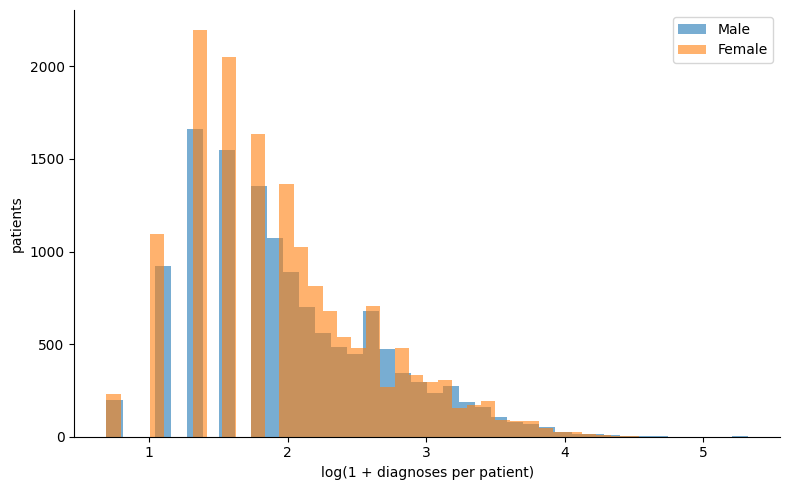

saved: /content/drive/MyDrive/PatientData/hgnn_statistics/plots_descriptive_simple/01_hyperedge_size_log_hist.png


In [ ]:
plt.figure(figsize=(8, 5))

for group in groups:
    df = pd.read_csv(group_path(group, "hyperedge_size_table.csv"))
    plt.hist(np.log1p(df["n_unique_diagnoses"]), bins=40, alpha=0.6, label=group)

clean_axes(
    xlabel="log(1 + diagnoses per patient)",
    ylabel="patients"
)
plt.legend()
save_plot("01_hyperedge_size_log_hist.png")

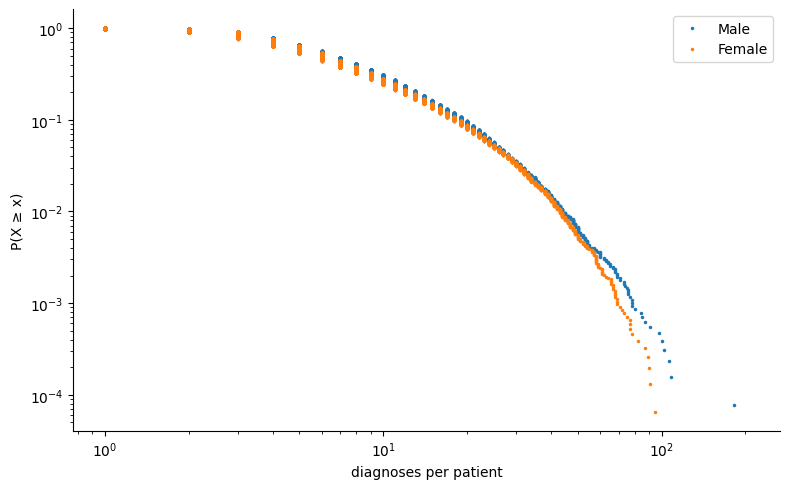

saved: /content/drive/MyDrive/PatientData/hgnn_statistics/plots_descriptive_simple/02_hyperedge_size_ccdf.png


In [ ]:
plt.figure(figsize=(8, 5))

for group in groups:
    df = pd.read_csv(group_path(group, "hyperedge_size_table.csv"))
    plot_ccdf(df["n_unique_diagnoses"], group)

plt.xscale("log")
plt.yscale("log")
clean_axes(
    xlabel="diagnoses per patient",
    ylabel="P(X ≥ x)"
)
plt.legend()
save_plot("02_hyperedge_size_ccdf.png")

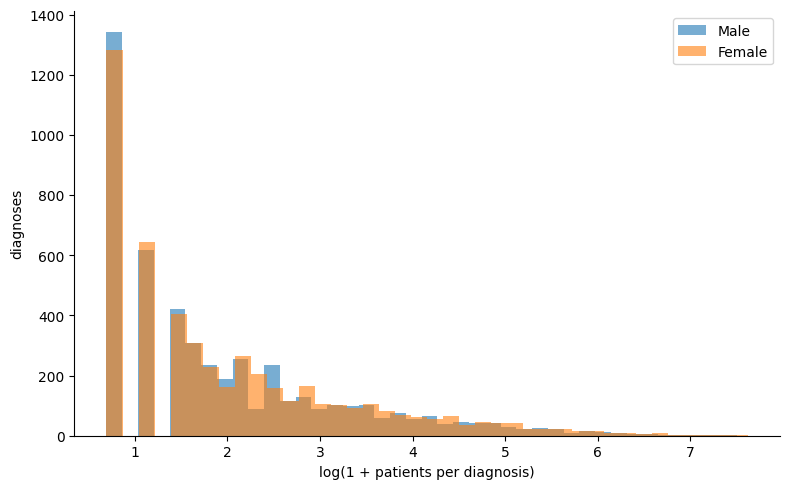

saved: /content/drive/MyDrive/PatientData/hgnn_statistics/plots_descriptive_simple/03_node_degree_log_hist.png


In [ ]:
plt.figure(figsize=(8, 5))

for group in groups:
    df = pd.read_csv(group_path(group, "node_degree_prevalence_table.csv"))
    plt.hist(np.log1p(df["degree_n_patients"]), bins=40, alpha=0.6, label=group)

clean_axes(
    xlabel="log(1 + patients per diagnosis)",
    ylabel="diagnoses"
)
plt.legend()
save_plot("03_node_degree_log_hist.png")

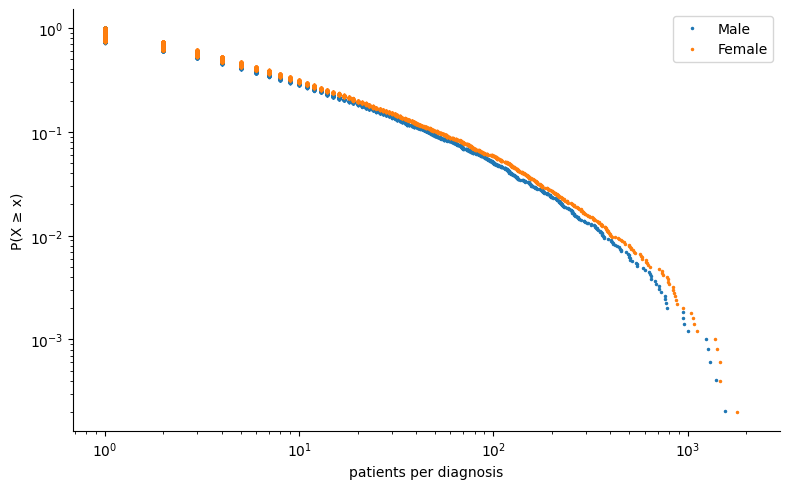

saved: /content/drive/MyDrive/PatientData/hgnn_statistics/plots_descriptive_simple/04_node_degree_ccdf.png


In [ ]:
plt.figure(figsize=(8, 5))

for group in groups:
    df = pd.read_csv(group_path(group, "node_degree_prevalence_table.csv"))
    plot_ccdf(df["degree_n_patients"], group)

plt.xscale("log")
plt.yscale("log")
clean_axes(
    xlabel="patients per diagnosis",
    ylabel="P(X ≥ x)"
)
plt.legend()
save_plot("04_node_degree_ccdf.png")

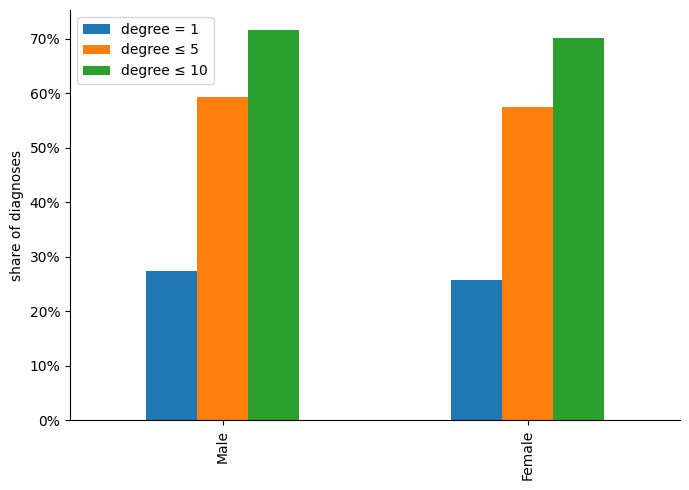

saved: /content/drive/MyDrive/PatientData/hgnn_statistics/plots_descriptive_simple/05_rare_diagnoses.png


In [ ]:
rare = pd.read_csv(output_dir / "combined_rare_diagnosis_stats.csv")

rare_plot = rare[[
    "group",
    "pct_degree_1",
    "pct_degree_le_5",
    "pct_degree_le_10"
]].copy()

rare_plot = rare_plot.set_index("group")

rare_plot.plot(kind="bar", figsize=(7, 5))

clean_axes(
    xlabel="",
    ylabel="share of diagnoses"
)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.legend(["degree = 1", "degree ≤ 5", "degree ≤ 10"])
save_plot("05_rare_diagnoses.png")

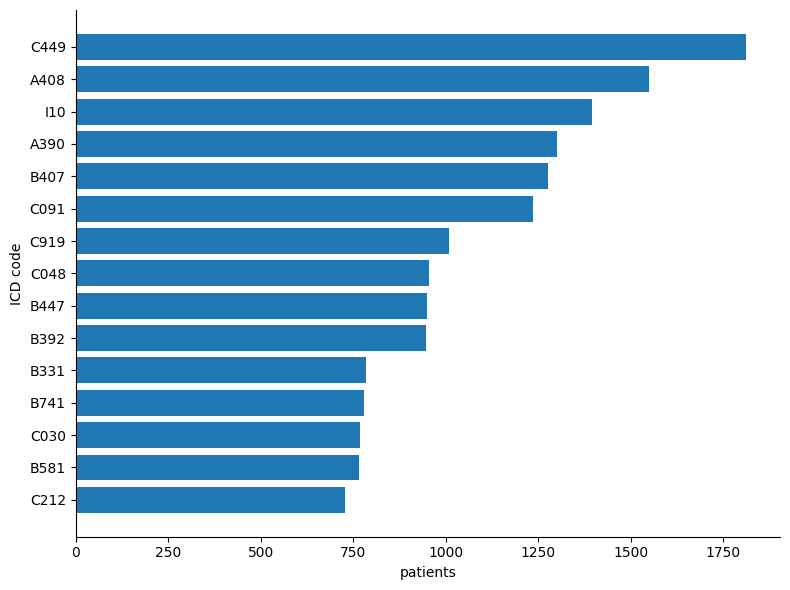

saved: /content/drive/MyDrive/PatientData/hgnn_statistics/plots_descriptive_simple/06_top_diagnoses_male.png


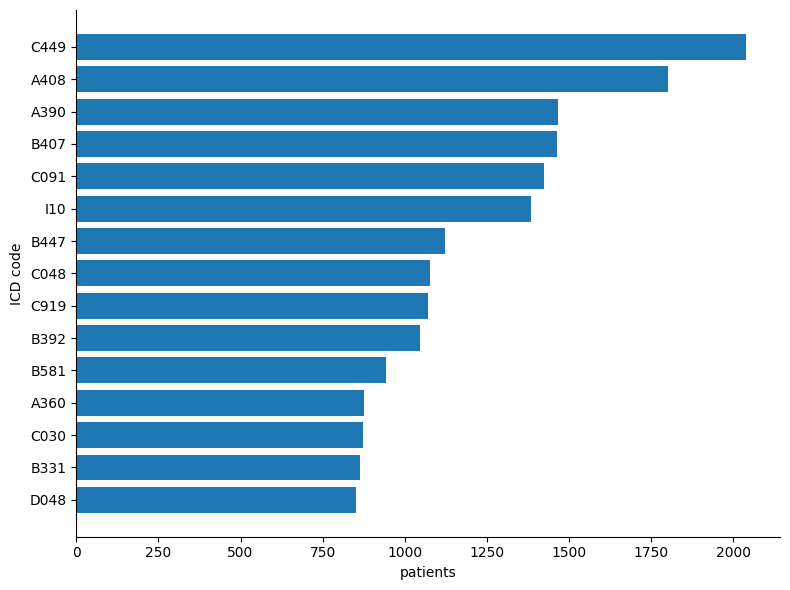

saved: /content/drive/MyDrive/PatientData/hgnn_statistics/plots_descriptive_simple/06_top_diagnoses_female.png


In [ ]:
for group in groups:
    df = pd.read_csv(group_path(group, "top_50_diagnoses.csv"))
    df = df.head(15).sort_values("n_patients")

    plt.figure(figsize=(8, 6))
    plt.barh(df["icd_code"], df["n_patients"])

    clean_axes(
        xlabel="patients",
        ylabel="ICD code"
    )
    save_plot(f"06_top_diagnoses_{group.lower()}.png")

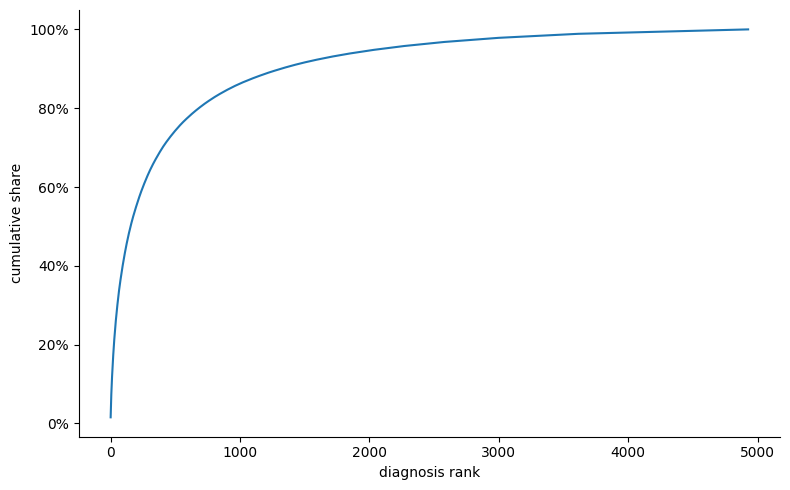

saved: /content/drive/MyDrive/PatientData/hgnn_statistics/plots_descriptive_simple/07_diagnosis_frequency_pareto_male.png


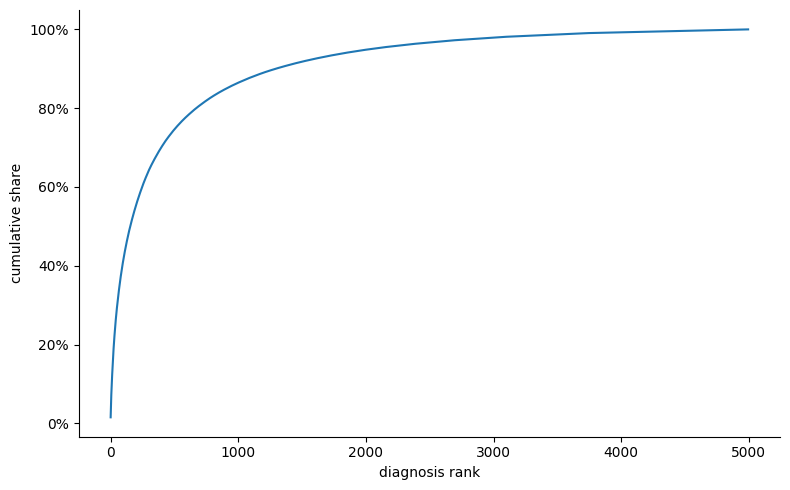

saved: /content/drive/MyDrive/PatientData/hgnn_statistics/plots_descriptive_simple/07_diagnosis_frequency_pareto_female.png


In [ ]:
for group in groups:
    df = pd.read_csv(group_path(group, "node_degree_prevalence_table.csv"))
    df = df.sort_values("degree_n_patients", ascending=False).copy()

    df["rank"] = np.arange(1, len(df) + 1)
    df["cumulative_share"] = (
        df["degree_n_patients"].cumsum() / df["degree_n_patients"].sum()
    )

    plt.figure(figsize=(8, 5))
    plt.plot(df["rank"], df["cumulative_share"])

    clean_axes(
        xlabel="diagnosis rank",
        ylabel="cumulative share"
    )
    plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    save_plot(f"07_diagnosis_frequency_pareto_{group.lower()}.png")

## Temporal descriptive statistics

**Question:** How do patient diagnosis histories change over time?

1. **Sequence length**  
   → How many unique diagnoses does a patient have in their ordered history?  
   This describes how complex the patient trajectory is.

2. **Follow-up years**  
   → How long is the patient observed between first and last diagnosis?  
   This is important because more diagnoses can appear simply because the patient is followed for longer.

3. **Diagnoses per year**  
   → How quickly do diagnoses accumulate over time?  
   This adjusts diagnosis burden by follow-up time.

4. **Lag days**  
   → How many days pass between one diagnosis and the next?  
   This describes the timing between consecutive diagnosis events.

5. **Zero-lag share**  
   → How often do consecutive diagnoses appear on the same date?  
   These should be interpreted carefully because same-day diagnoses do not have a clear temporal order.

6. **Same-day ties**  
   → How often do multiple diagnoses first appear on the same day?  
   This shows how often temporal ordering is ambiguous.

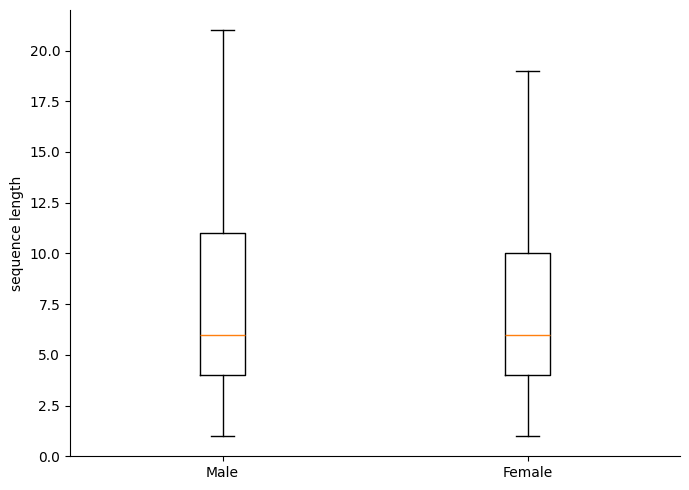

saved: /content/drive/MyDrive/PatientData/hgnn_statistics/plots_descriptive_simple/08_sequence_length_boxplot.png


In [ ]:
sequence_data = []
labels = []

for group in groups:
    df = pd.read_csv(group_path(group, "patient_temporal_summary.csv"))
    sequence_data.append(df["sequence_length"].dropna())
    labels.append(group)

plt.figure(figsize=(7, 5))
plt.boxplot(sequence_data, labels=labels, showfliers=False)

clean_axes(
    xlabel="",
    ylabel="sequence length"
)
save_plot("08_sequence_length_boxplot.png")

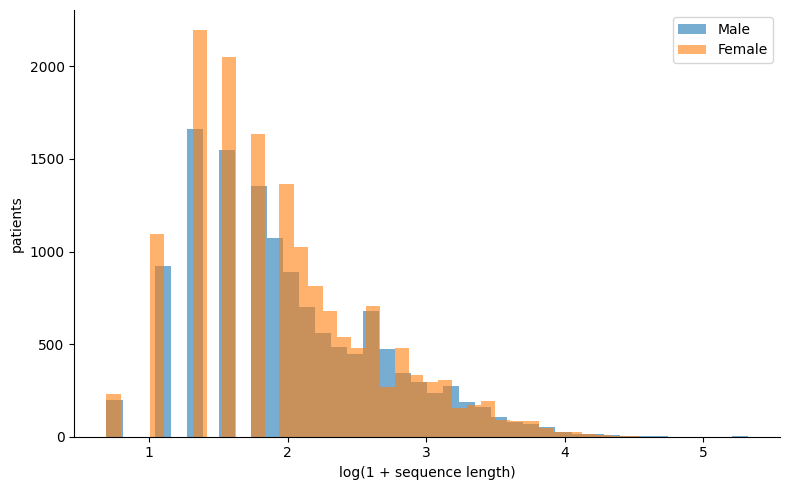

saved: /content/drive/MyDrive/PatientData/hgnn_statistics/plots_descriptive_simple/09_sequence_length_log_hist.png


In [ ]:
plt.figure(figsize=(8, 5))

for group in groups:
    df = pd.read_csv(group_path(group, "patient_temporal_summary.csv"))
    plt.hist(np.log1p(df["sequence_length"]), bins=40, alpha=0.6, label=group)

clean_axes(
    xlabel="log(1 + sequence length)",
    ylabel="patients"
)
plt.legend()
save_plot("09_sequence_length_log_hist.png")

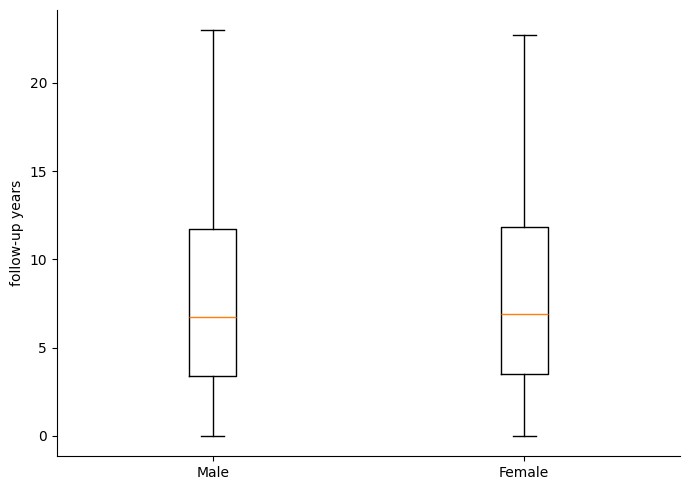

saved: /content/drive/MyDrive/PatientData/hgnn_statistics/plots_descriptive_simple/10_follow_up_years_boxplot.png


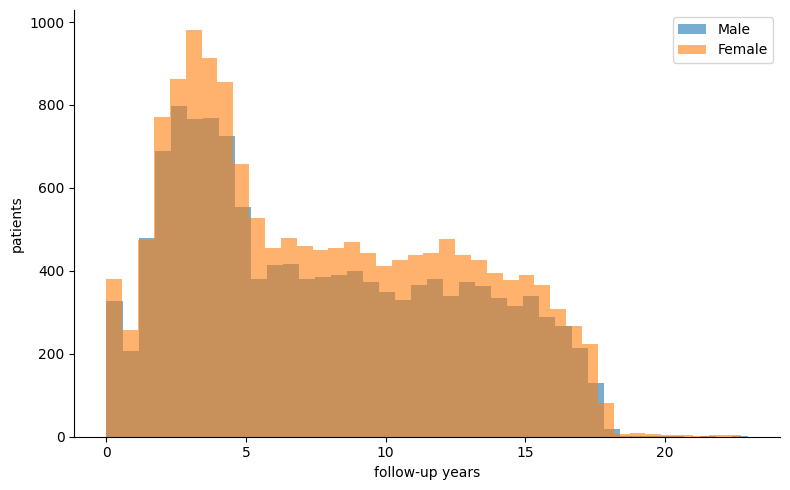

saved: /content/drive/MyDrive/PatientData/hgnn_statistics/plots_descriptive_simple/11_follow_up_years_hist.png


In [ ]:
followup_data = []
labels = []

for group in groups:
    df = pd.read_csv(group_path(group, "patient_temporal_summary.csv"))
    followup_data.append(df["follow_up_years"].dropna())
    labels.append(group)

plt.figure(figsize=(7, 5))
plt.boxplot(followup_data, labels=labels, showfliers=False)

clean_axes(
    xlabel="",
    ylabel="follow-up years"
)
save_plot("10_follow_up_years_boxplot.png")

plt.figure(figsize=(8, 5))

for group in groups:
    df = pd.read_csv(group_path(group, "patient_temporal_summary.csv"))
    values = df["follow_up_years"].replace([np.inf, -np.inf], np.nan).dropna()
    plt.hist(values, bins=40, alpha=0.6, label=group)

clean_axes(
    xlabel="follow-up years",
    ylabel="patients"
)
plt.legend()
save_plot("11_follow_up_years_hist.png")

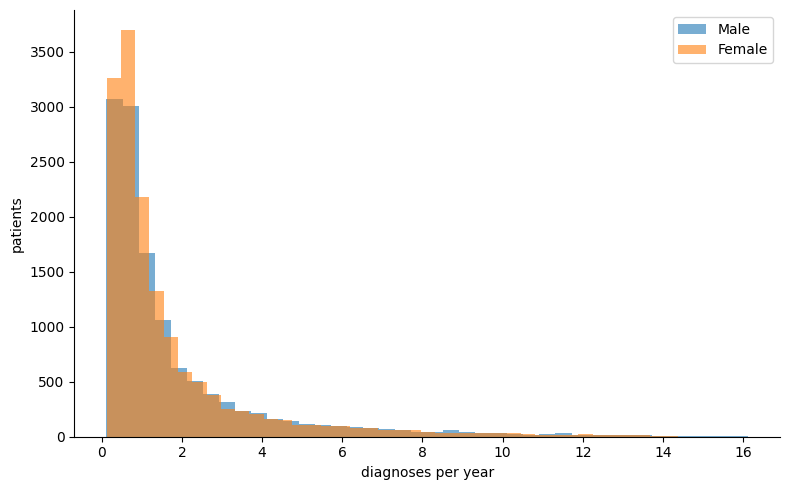

saved: /content/drive/MyDrive/PatientData/hgnn_statistics/plots_descriptive_simple/12_diagnoses_per_year_hist.png


In [ ]:
plt.figure(figsize=(8, 5))

for group in groups:
    df = pd.read_csv(group_path(group, "patient_temporal_summary.csv"))
    values = df["diagnoses_per_year"].replace([np.inf, -np.inf], np.nan).dropna()
    values = values[values <= values.quantile(0.99)]

    plt.hist(values, bins=40, alpha=0.6, label=group)

clean_axes(
    xlabel="diagnoses per year",
    ylabel="patients"
)
plt.legend()
save_plot("12_diagnoses_per_year_hist.png")

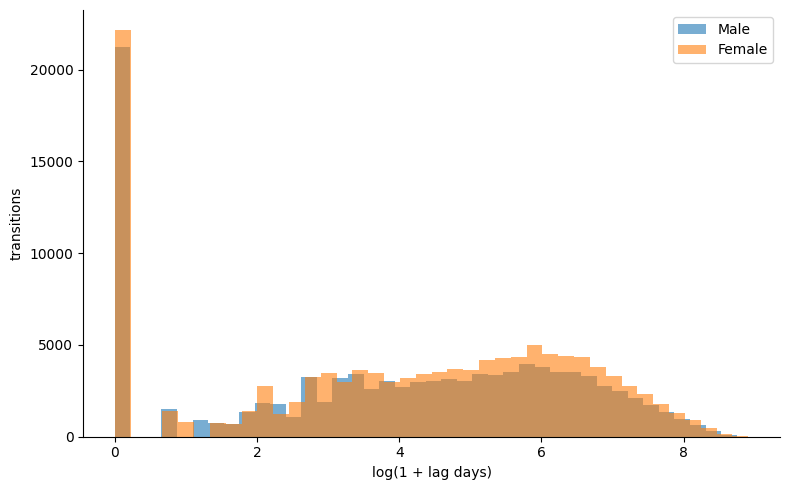

saved: /content/drive/MyDrive/PatientData/hgnn_statistics/plots_descriptive_simple/13_lag_days_log_hist.png


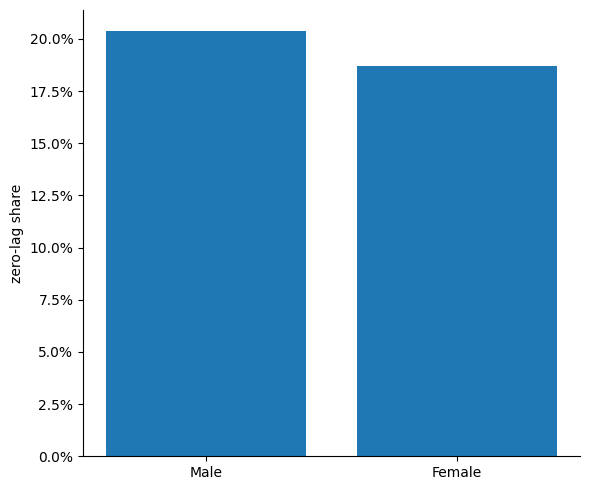

saved: /content/drive/MyDrive/PatientData/hgnn_statistics/plots_descriptive_simple/14_zero_lag_share.png


In [ ]:
plt.figure(figsize=(8, 5))

for group in groups:
    df = pd.read_csv(group_path(group, "consecutive_transition_rows.csv"))
    values = df["lag_days"].replace([np.inf, -np.inf], np.nan).dropna()
    values = values[values >= 0]

    plt.hist(np.log1p(values), bins=40, alpha=0.6, label=group)

clean_axes(
    xlabel="log(1 + lag days)",
    ylabel="transitions"
)
plt.legend()
save_plot("13_lag_days_log_hist.png")
lag_quality = pd.read_csv(output_dir / "combined_lag_quality_summary.csv")

plt.figure(figsize=(6, 5))
plt.bar(lag_quality["group"], lag_quality["pct_zero_lags"])

clean_axes(
    xlabel="",
    ylabel="zero-lag share"
)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
save_plot("14_zero_lag_share.png")


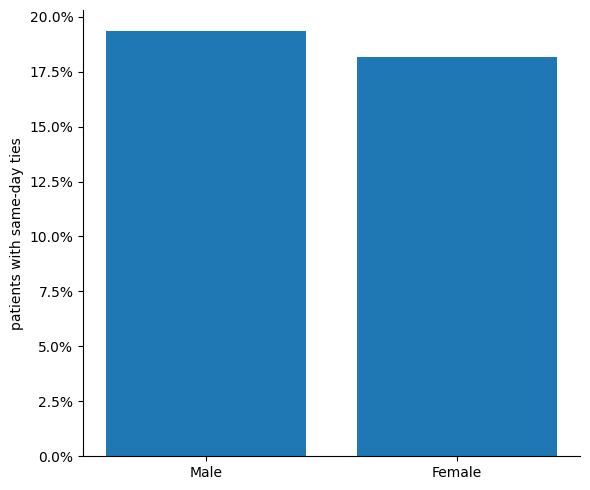

saved: /content/drive/MyDrive/PatientData/hgnn_statistics/plots_descriptive_simple/15_same_day_ties.png


In [ ]:
same_day = pd.read_csv(output_dir / "combined_same_day_tie_summary.csv")

plt.figure(figsize=(6, 5))
plt.bar(same_day["group"], same_day["pct_patients_with_same_day_tie"])

clean_axes(
    xlabel="",
    ylabel="patients with same-day ties"
)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
save_plot("15_same_day_ties.png")

PREDICTION-TASK STATISTICS

Question: What does the next-diagnosis prediction task look like?

1. Prefix length
   -> How many previous diagnoses are used to predict the next one?

2. Number of prefix samples
   -> How many prediction examples are available?

3. Target distribution
   -> Which diagnoses most often appear as the next diagnosis?

4. Most common target share
   -> Is the task dominated by one very frequent next diagnosis?

5. Rare targets
   -> How many next-diagnosis labels appear only once?

6. Target Pareto plot
   -> Do a few diagnoses cover most prediction samples?

Why these are useful:
They show whether the prediction task has enough samples, how many possible target diagnoses exist, and whether the labels are imbalanced.

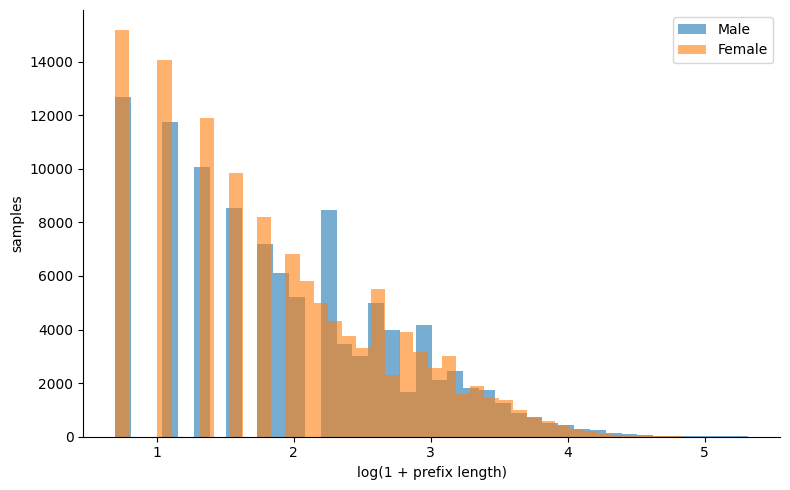

saved: /content/drive/MyDrive/PatientData/hgnn_statistics/plots_descriptive_simple/16_prefix_length_log_hist.png


In [ ]:
plt.figure(figsize=(8, 5))

for group in groups:
    df = pd.read_csv(group_path(group, "prefix_prediction_samples.csv"))
    plt.hist(np.log1p(df["prefix_length"]), bins=40, alpha=0.6, label=group)

clean_axes(
    xlabel="log(1 + prefix length)",
    ylabel="samples"
)
plt.legend()
save_plot("16_prefix_length_log_hist.png")

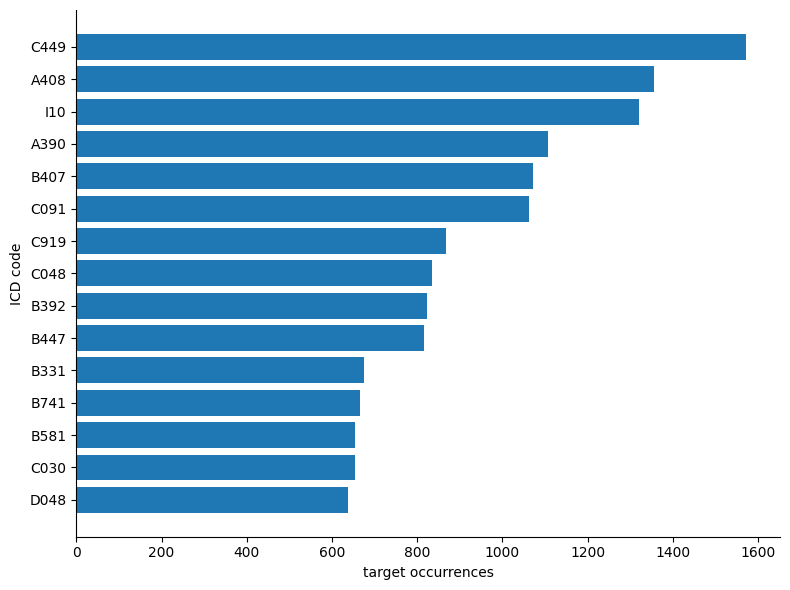

saved: /content/drive/MyDrive/PatientData/hgnn_statistics/plots_descriptive_simple/17_top_targets_male.png


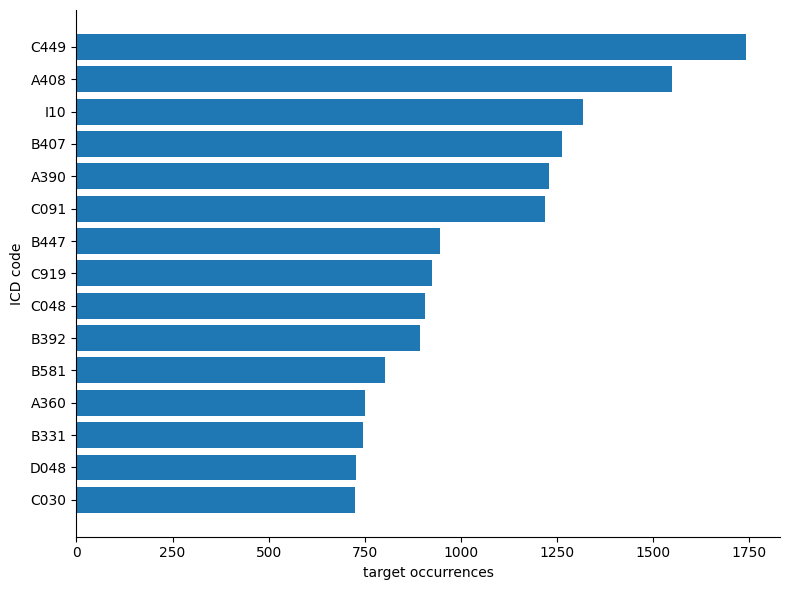

saved: /content/drive/MyDrive/PatientData/hgnn_statistics/plots_descriptive_simple/17_top_targets_female.png


In [ ]:
for group in groups:
    df = pd.read_csv(group_path(group, "target_distribution_for_next_disease.csv"))
    df = df.head(15).sort_values("n_target_occurrences")

    plt.figure(figsize=(8, 6))
    plt.barh(df["icd_code"], df["n_target_occurrences"])

    clean_axes(
        xlabel="target occurrences",
        ylabel="ICD code"
    )
    save_plot(f"17_top_targets_{group.lower()}.png")

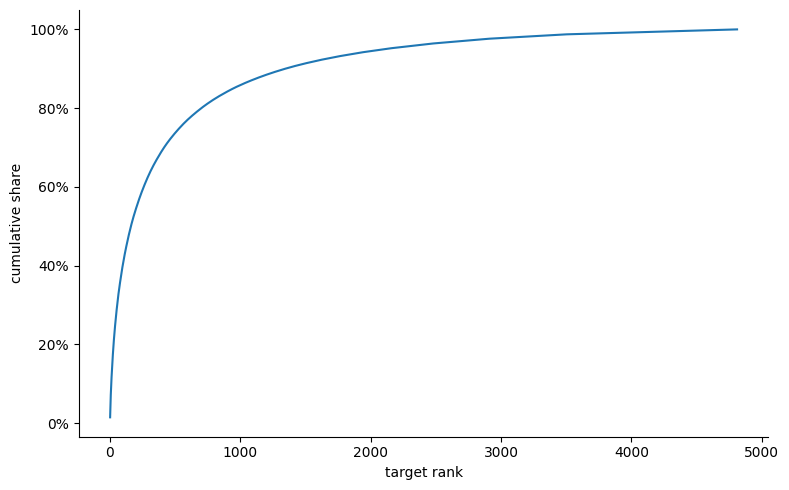

saved: /content/drive/MyDrive/PatientData/hgnn_statistics/plots_descriptive_simple/18_target_pareto_male.png


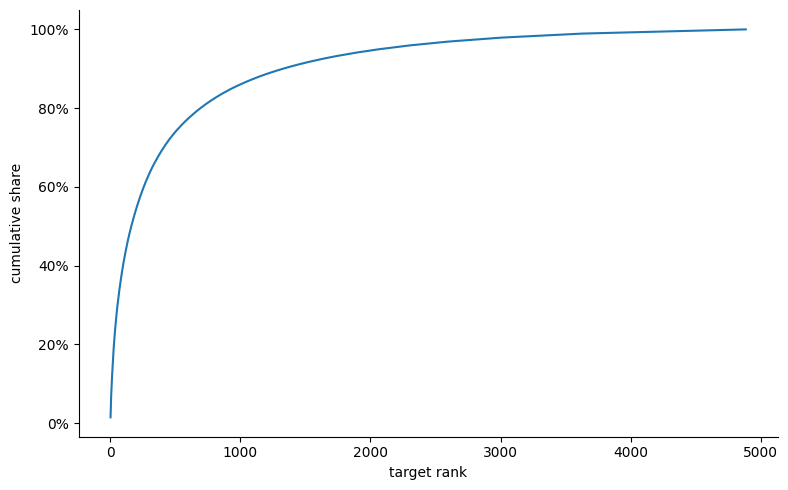

saved: /content/drive/MyDrive/PatientData/hgnn_statistics/plots_descriptive_simple/18_target_pareto_female.png


In [ ]:
for group in groups:
    df = pd.read_csv(group_path(group, "target_distribution_for_next_disease.csv"))
    df = df.sort_values("n_target_occurrences", ascending=False).copy()

    df["rank"] = np.arange(1, len(df) + 1)
    df["cumulative_share"] = (
        df["n_target_occurrences"].cumsum()
        / df["n_target_occurrences"].sum()
    )

    plt.figure(figsize=(8, 5))
    plt.plot(df["rank"], df["cumulative_share"])

    clean_axes(
        xlabel="target rank",
        ylabel="cumulative share"
    )
    plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    save_plot(f"18_target_pareto_{group.lower()}.png")

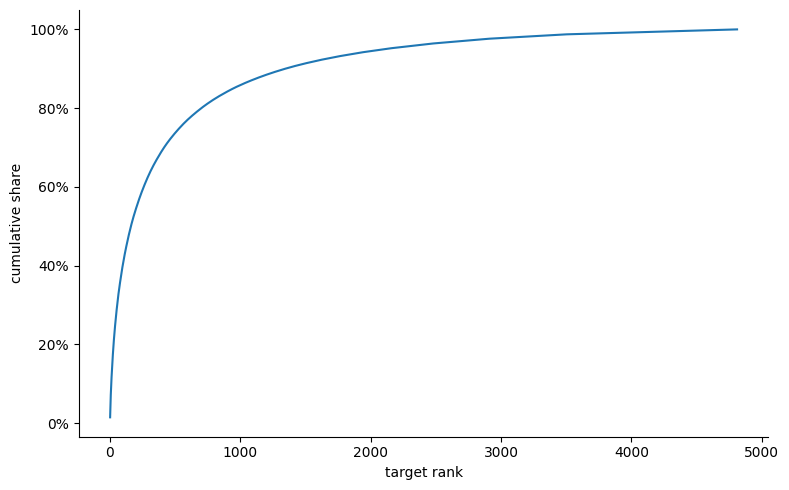

saved: /content/drive/MyDrive/PatientData/hgnn_statistics/plots_descriptive_simple/18_target_pareto_male.png


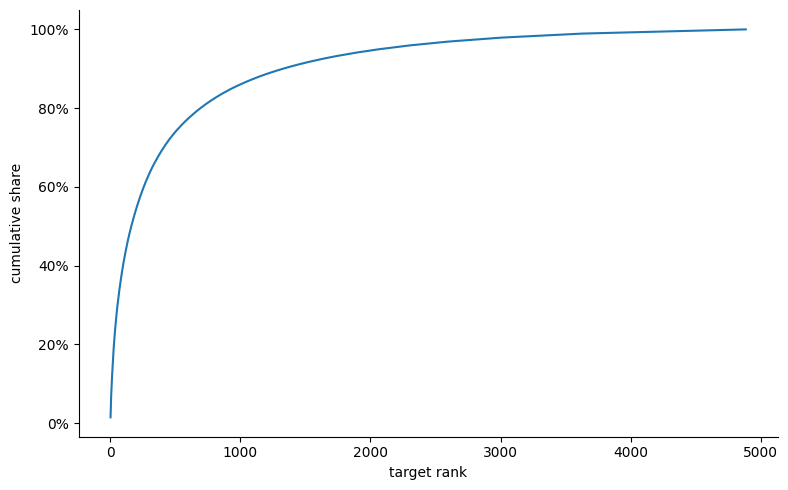

saved: /content/drive/MyDrive/PatientData/hgnn_statistics/plots_descriptive_simple/18_target_pareto_female.png


In [ ]:
for group in groups:
    df = pd.read_csv(group_path(group, "target_distribution_for_next_disease.csv"))
    df = df.sort_values("n_target_occurrences", ascending=False).copy()

    df["rank"] = np.arange(1, len(df) + 1)
    df["cumulative_share"] = (
        df["n_target_occurrences"].cumsum()
        / df["n_target_occurrences"].sum()
    )

    plt.figure(figsize=(8, 5))
    plt.plot(df["rank"], df["cumulative_share"])

    clean_axes(
        xlabel="target rank",
        ylabel="cumulative share"
    )
    plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    save_plot(f"18_target_pareto_{group.lower()}.png")

## Sex × age-group visualizations

**Question:** Do disease burden, temporal history, and prediction difficulty differ by sex and baseline age group?

Sex and age group are not new hypergraph nodes.  
They are patient-level labels used to split the patient-diagnosis hypergraph into subgroup hypergraphs.

Useful plots:

1. **Median diagnoses per patient by sex and age group**  
   → Shows typical multimorbidity burden in each subgroup.

2. **Share of patients with ≥10 diagnoses by sex and age group**  
   → Shows how common high multimorbidity burden is.

3. **Median sequence length by sex and age group**  
   → Shows whether older groups have longer diagnosis histories.

4. **Median diagnoses per year by sex and age group**  
   → Shows whether diagnoses accumulate faster in some groups.

5. **Most common target share by sex and age group**  
   → Shows whether the next-diagnosis prediction task is more imbalanced in some groups.

In [ ]:
sex_age_summary = pd.read_csv(
    output_dir / "KEY_SUMMARY_BY_SEX_AGE_FOR_REPORT.csv"
)

patient_burden_age = pd.read_csv(
    output_dir / "PATIENT_BURDEN_BY_SEX_AGE_FOR_PLOTS.csv"
)

# Clean age group text
sex_age_summary["age_group"] = sex_age_summary["age_group"].astype(str).str.strip()
patient_burden_age["age_group"] = patient_burden_age["age_group"].astype(str).str.strip()

# Extract age start for correct sorting
sex_age_summary["age_start"] = (
    sex_age_summary["age_group"]
    .str.extract(r"(\d+)")
    .astype(float)
)

patient_burden_age["age_start"] = (
    patient_burden_age["age_group"]
    .str.extract(r"(\d+)")
    .astype(float)
)

sex_age_summary = sex_age_summary.sort_values(["sex", "age_start"])
patient_burden_age = patient_burden_age.sort_values(["sex", "age_start"])

display(sex_age_summary.head())
display(patient_burden_age.head())

,sex,age_group,n_hyperedges_patients,n_nodes_diagnoses,n_memberships_patient_diagnosis,incidence_density,incidence_sparsity,avg_hyperedge_size,median_hyperedge_size,min_hyperedge_size,...,median_diagnoses_per_year,n_prefix_samples,n_unique_target_diagnoses,most_common_target_count,most_common_target_share,n_targets_with_1_sample,pct_targets_with_1_sample,top_5_target_share,top_10_target_share,age_start
0,Female,20 bis 24 Jahre,953.0,1299.0,5260.0,0.004249,0.995751,5.519412,4.0,1.0,...,0.678430,4307.0,1180.0,69.0,0.016020,595.0,0.504237,0.069190,0.115626,20.0
1,Female,25 bis 29 Jahre,1294.0,1913.0,10196.0,0.004119,0.995881,7.879444,5.0,1.0,...,0.716879,8902.0,1822.0,135.0,0.015165,861.0,0.472558,0.063581,0.105931,25.0
2,Female,30 bis 34 Jahre,658.0,1151.0,3511.0,0.004636,0.995364,5.335866,4.0,1.0,...,0.643613,2853.0,1035.0,45.0,0.015773,612.0,0.591304,0.063442,0.110060,30.0
3,Female,35 bis 39 Jahre,1302.0,2104.0,11891.0,0.004341,0.995659,9.132873,6.0,1.0,...,0.869963,10589.0,2020.0,163.0,0.015393,924.0,0.457426,0.064406,0.107092,35.0
4,Female,40 bis 44 Jahre,483.0,1324.0,4629.0,0.007239,0.992761,9.583851,7.0,1.0,...,1.793372,4146.0,1266.0,108.0,0.026049,663.0,0.523697,0.070429,0.111433,40.0


,sex,age_group,hyperedge_index,n_unique_diagnoses,age_start
0,Female,20 bis 24 Jahre,19,5,20.0
1,Female,20 bis 24 Jahre,325,4,20.0
2,Female,20 bis 24 Jahre,683,12,20.0
3,Female,20 bis 24 Jahre,686,21,20.0
4,Female,20 bis 24 Jahre,729,19,20.0


In [ ]:
plot_dir_age = output_dir / "plots_by_sex_age"
plot_dir_age.mkdir(parents=True, exist_ok=True)

def save_plot_age(filename):
    path = plot_dir_age / filename
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    print("saved:", path)

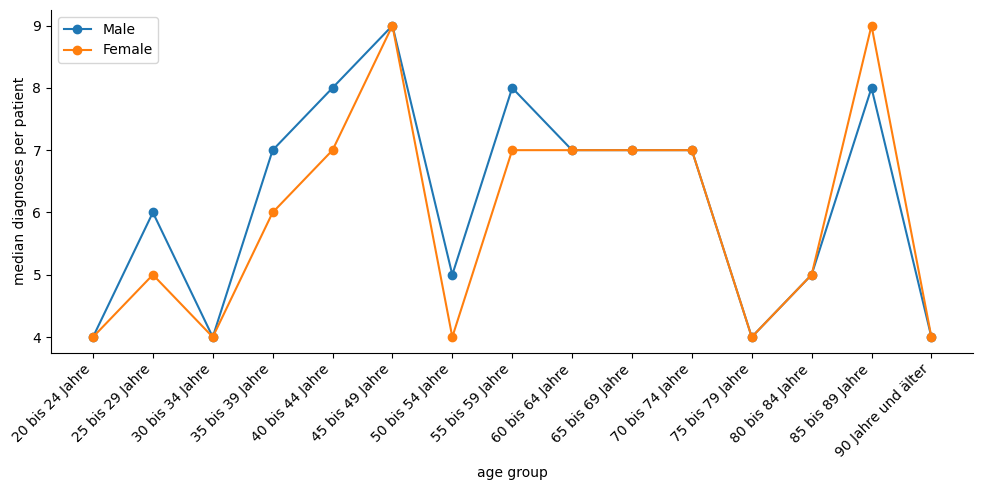

saved: /content/drive/MyDrive/PatientData/hgnn_statistics/plots_by_sex_age/A01_median_hyperedge_size_by_sex_age.png


In [ ]:
plt.figure(figsize=(10, 5))

for sex in ["Male", "Female"]:
    df = sex_age_summary[sex_age_summary["sex"] == sex].copy()
    df = df.sort_values("age_start")

    plt.plot(
        df["age_group"],
        df["median_hyperedge_size"],
        marker="o",
        label=sex
    )

clean_axes(
    xlabel="age group",
    ylabel="median diagnoses per patient"
)

plt.xticks(rotation=45, ha="right")
plt.legend()
save_plot_age("A01_median_hyperedge_size_by_sex_age.png")

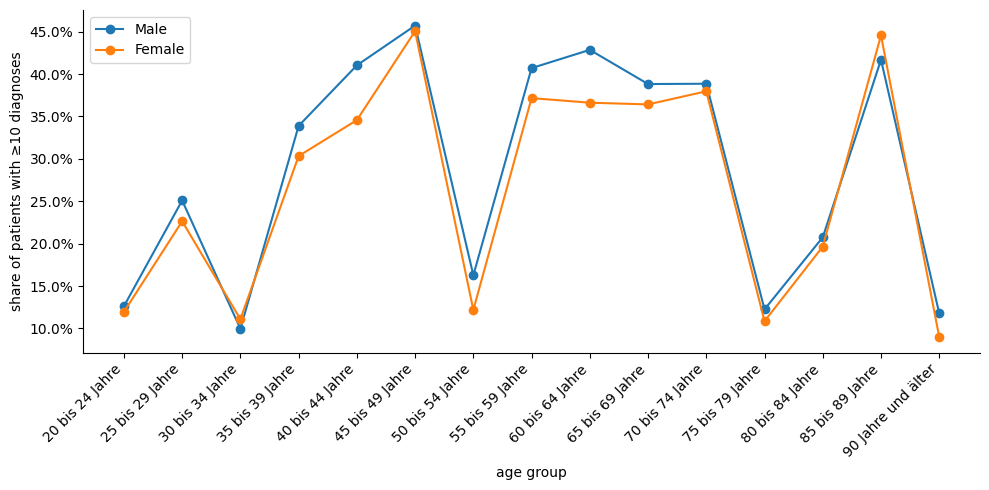

saved: /content/drive/MyDrive/PatientData/hgnn_statistics/plots_by_sex_age/A03_pct_ge_10_diagnoses_by_sex_age.png


In [ ]:
plt.figure(figsize=(10, 5))

for sex in ["Male", "Female"]:
    df = sex_age_summary[sex_age_summary["sex"] == sex].copy()
    df = df.sort_values("age_start")

    plt.plot(
        df["age_group"],
        df["pct_ge_10_diag"],
        marker="o",
        label=sex
    )

clean_axes(
    xlabel="age group",
    ylabel="share of patients with ≥10 diagnoses"
)

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.xticks(rotation=45, ha="right")
plt.legend()
save_plot_age("A03_pct_ge_10_diagnoses_by_sex_age.png")

In [ ]:

# Median sequence length by sex and age group

plt.figure(figsize=(10, 5))

for sex in ["Male", "Female"]:
    df = sex_age_summary[sex_age_summary["sex"] == sex].copy()
    df = df.sort_values("age_start")

    plt.plot(
        df["age_group"],
        df["median_sequence_length"],
        marker="o",
        label=sex
    )

clean_axes(
    xlabel="age group",
    ylabel="median sequence length"
)

plt.xticks(rotation=45, ha="right")
plt.legend()
save_plot_age("A04_median_sequence_length_by_sex_age.png")

In [ ]:

# Median diagnoses per year by sex and age group


plt.figure(figsize=(10, 5))

for sex in ["Male", "Female"]:
    df = sex_age_summary[sex_age_summary["sex"] == sex].copy()
    df = df.sort_values("age_start")

    plt.plot(
        df["age_group"],
        df["median_diagnoses_per_year"],
        marker="o",
        label=sex
    )

clean_axes(
    xlabel="age group",
    ylabel="median diagnoses per year"
)

plt.xticks(rotation=45, ha="right")
plt.legend()
save_plot_age("A05_median_diagnoses_per_year_by_sex_age.png")

In [ ]:
# Rare targets by sex and age group

plt.figure(figsize=(10, 5))

for sex in ["Male", "Female"]:
    df = sex_age_summary[sex_age_summary["sex"] == sex].copy()
    df = df.sort_values("age_start")

    plt.plot(
        df["age_group"],
        df["pct_targets_with_1_sample"],
        marker="o",
        label=sex
    )

clean_axes(
    xlabel="age group",
    ylabel="share of targets with one sample"
)

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.xticks(rotation=45, ha="right")
plt.legend()
save_plot_age("A07_rare_targets_by_sex_age.png")